# Hier-COS Current-Run Trade-Off Plots

This notebook aggregates seeded Hier-COS output directories from
`/scratch/g.saggini1/outputs`. The run matrix is declared as a list of compact
requests in `RUN_REQUESTS`; each request expands into an output directory name,
a plot label, and a short code used in the summary table.

Request grammar: `(softmax, weighting, priority, *options)`.

- `softmax`: `'global'` or `'level'`;
- `weighting`: `'equal'`, `'kl_leaf'`, or `'mb'` (marginal branching);
- `priority`: `'no_lex'`, `'coarse_first'`, `'fine_first'`, `'projection'`, or
  `'hcc'` (projection is available only with level softmax; `hcc` is available
  only at the matched baseline settings, i.e. `kl_leaf` and an orthonormal frame);
- options are order-independent: a frame (`'orthonormal'` or `'identity'`),
  `'resnet50'`, a
  positive feature dimension for no-lex baseline or projection runs, `'advantage'`
  for projection runs, and/or a dataset-filter collection.

`hcc` is the Hierarchical Constraint Cascade applied after the fixed
classifier: it is an output-space constraint, not a gradient-space method, and
it is a binary on/off switch active for the whole run rather than a schedule.
`model.projection` stays disabled on that arm so the two projection mechanisms
are not confounded, which makes it a single-variable change from the
global-softmax `kl_leaf` no-lex baseline.

`projection` is the only LH-DNN-style architecture: a shared channel-wise PReLU
is always inserted before the level heads, and the projection matrix uses the
LH-DNN form `A[b] = [W_0; ...; W_(l-1)] * rho_prime(k[b])`, making the protected
subspace sample-dependent. The earlier batch-shared-`A` variant (no PReLU
derivative) has been removed.

Two ablations are toggled separately because their comparability differs:

- `INCLUDE_PRETRAINING_ABLATION` (Aircraft): pretrained/scratch x
  orthonormal/identity. The canonical Aircraft baseline is already a pretrained
  ResNet-50, so pretrained-versus-scratch is single-variable against it.
- `INCLUDE_RESNET50_ABLATION` (CIFAR-100): the same grid with
  `model.variant=haframe_resnet50` held fixed and only `model.pretrained`
  toggled. Pretrained-versus-scratch is single-variable *within this list only*.
  The CIFAR-100 `kl_leaf` no-lex baseline plotted alongside it is
  WideResNet-28-8, so those points are not a controlled comparison against it.

FPA, weighted AP, and level accuracy are higher-is-better; TICE and AHD are
lower-is-better. Points, bars, and error bars are mean +/- sample standard
deviation across training seeds. A trailing `*` marks a run whose
`test_metrics.yaml` predates the top-down/independent selection split, so its
checkpoint was chosen by a single criterion.

### Selection and metric family

Set `DECODER` and `READOUT` in the setup cell. Every metric is read from the
checkpoint selected for that same decoder, so independent and top-down checkpoint
selection are never crossed. `native` reads `test_metrics.yaml`; `node_score` and
`subspace_norm` read the corresponding cell from
`posthoc_inference_test_metrics.yaml`. With `RUN_INFERENCE=True`, the discovery
cell silently generates missing files behind one updating loading line. An existing
incompatible file is replaced only with `OVERWRITE_INFERENCE=True`. Anything still
unavailable is reported and is never silently replaced with native inference.

Top-down decoding is available for completeness, but its FPA--TICE view is
degenerate: its predicted path is consistent by construction, so `tice_topdown` is
exactly zero and `fpa_topdown` equals top-down fine accuracy. Independent decoding
is therefore the meaningful default for the trade-off figures.

### Figure format

Figures are authored at their final printed size (6.3 in, an A4 text block with
2.5 cm margins) in the same style as `analysis/datasets_analysis.ipynb`, and are
written to `FIGURE_DIR` as PDF and PNG. Include them with `width=\linewidth`
and no further scaling: any resizing in LaTeX shrinks the fonts along with the
artwork. Figure titles are omitted on purpose — they belong in the caption.

One dataset per row rather than three panels side by side: at 6.3 in a 1x3 row
leaves about 2 in per panel, which is not enough for the direct labels or for
grouped bars once a run matrix grows.

In [15]:
from pathlib import Path
import sys

# The helper lives in notebooks/utils; also look upward so the notebook works
# when the kernel starts at the repository root.
SEARCH_PATHS = [Path.cwd(), *(parent / 'notebooks' / 'utils' for parent in (Path.cwd(), *Path.cwd().parents))]
HELPER_DIR = next((path for path in SEARCH_PATHS if (path / 'current_run_plot_utils.py').is_file()), None)
if HELPER_DIR is None:
    raise FileNotFoundError('Run this notebook from the repository tree so notebooks/utils is discoverable.')
sys.path.insert(0, str(HELPER_DIR))

import matplotlib.pyplot as plt

from current_run_plot_utils import (
    check_encoding, discover_rows, encode_rows, evaluate_missing_readouts,
    model_reference_specs,
    plot_level_accuracy_deltas, plot_tradeoff,
    print_availability, print_reference_availability, print_summary,
    use_paper_style,
)

use_paper_style()

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
# Each figure is written as a PDF and a PNG at its authored printed size.
SAVE_FIGURES = True
FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'current_runs' / 'hiercos'

# Every metric uses the checkpoint selected for this decoder. Explicit
# readouts require posthoc_inference_test_metrics.yaml in each seed directory.
DECODER = 'independent'          # 'independent' | 'topdown'
READOUT = 'native'               # 'native' | 'node_score' | 'subspace_norm'
# For an HCC-trained run, native includes its HCC projection; the two named
# readouts are the explicit untransformed inference cells.
SUBSPACE_SCORE_SPACE = 'probability'  # used only by subspace_norm
RUN_INFERENCE = True              # silently fill missing non-native readouts
OVERWRITE_INFERENCE = False       # replace an existing incompatible result file
INFERENCE_DEVICE = None           # None uses the run config/default device

INCLUDE_LHDNN_PROJECTION = True
INCLUDE_REFERENCE_MODELS = True
INCLUDE_PRETRAINING_ABLATION = False   # Aircraft pretrained/scratch x orthonormal/identity
INCLUDE_RESNET50_ABLATION = False      # CIFAR-100 pretrained/scratch ResNet-50 x orthonormal/identity

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}

In [16]:
RUN_REQUESTS = [
    # ('global', 'equal', 'no_lex'),
    ('global', 'kl_leaf', 'no_lex'),
    # ('global', 'kl_leaf', 'no_lex', 'identity'),
    # ('global', 'kl_leaf', 'no_lex', 'block'),
    #('global', 'equal', 'coarse_first'),
    #('global', 'equal', 'coarse_first', 'identity'),
    # ('global', 'equal', 'fine_first'),
    ('global', 'kl_leaf', 'coarse_first'),
    #('global', 'kl_leaf', 'hcc'),
    # ('level', 'kl_leaf', 'no_lex'),
    ('level', 'kl_leaf', 'no_lex', 'identity'),
    ('level', 'kl_leaf', 'no_lex', 'block'),
    # ('level', 'equal', 'no_lex', 'identity'),
    # ('level', 'equal', 'no_lex', 'block'),
    # ('level', 'equal', 'coarse_first'),
    # ('level', 'kl_leaf', 'coarse_first', 'identity'),
    # ('level', 'kl_leaf', 'coarse_first', 'block'),
    # ('level', 'equal', 'coarse_first', 'identity'),
    # ('level', 'equal', 'coarse_first', 'block'),
]

if INCLUDE_LHDNN_PROJECTION:
    RUN_REQUESTS.extend([
        # ('level', 'kl_leaf', 'projection', 'block'),
        # ('level', 'kl_leaf', 'projection', 'identity'),
        ('level', 'kl_leaf', 'projection', 'block', 512),
        ('level', 'kl_leaf', 'projection', 'identity', 512),
        # ('level', 'kl_leaf', 'projection', 'identity', 512, 'advantage'),
        
        ('level', 'equal', 'projection', 'block', 512),
        ('level', 'equal', 'projection', 'identity', 512, {'aircraft'}),

        ('level', 'mb', 'projection', 'identity', 512, {'aircraft'}),
        # ('level', 'kl_leaf', 'projection', 'identity', 512, 'advantage', {'cub200'}),
    ])

# (pretraining, frame) with pretraining in {'pretrained', 'scratch'}.
# Aircraft-only; see scripts/hiercos/run_hiercos_aircraft_pretraining_ablation.sh.
PRETRAINING_ABLATION_REQUESTS = [
    ('pretrained', 'orthonormal'),
    ('pretrained', 'identity'),
    ('scratch', 'orthonormal'),
    ('scratch', 'identity'),
]

# Same shape, CIFAR-100-only; see
# scripts/hiercos/run_hiercos_cifar100_resnet50_pretrained.sh.
RESNET50_ABLATION_REQUESTS = [
    ('pretrained', 'orthonormal'),
    # ('pretrained', 'identity'),
    ('scratch', 'orthonormal'),
    ('scratch', 'identity'),
]

In [17]:
SOFTMAX_SPECS = {
    'global': {'loss': 'global_softmax_ce_reg', 'label': 'Global', 'code': 'G'},
    'level': {'loss': 'level_softmax_ce_reg', 'label': 'Level', 'code': 'L'},
}

LOSS_COLORS = {'Global': '#0072B2', 'Level': '#D55E00'}
PRIORITY_LABELS = {
    'no_lex': 'No lex', 'coarse_first': 'Coarse-first lex',
    'fine_first': 'Fine-first lex', 'projection': 'LH-projection',
    'hcc': 'HCC constraint',
}
PRIORITY_CODES = {'no_lex': 'N', 'coarse_first': 'C', 'fine_first': 'F', 'projection': 'P',
                  'hcc': 'H'}

# Colour encodes the mechanism, using the same vocabulary as every other
# notebook.
MECHANISM_BY_PRIORITY = {
    'no_lex': 'baseline', 'coarse_first': 'lex',
    'fine_first': 'lex', 'projection': 'projection',
    'hcc': 'hcc',
}
WEIGHT_CODES = {'equal': 'E', 'kl_leaf': 'K', 'mb': 'MB'}
WEIGHT_LABELS = {
    'equal': 'Equal', 'kl_leaf': 'kl_leaf', 'mb': 'Marginal branching',
}
FRAMES = {'orthonormal', 'identity', 'block'}
FRAME_LABELS = {'orthonormal': 'Random', 'identity': 'Identity', 'block': 'Block random'}


def run_suffix(priority, weight, frame, backbone_variant=None,
               feature_dim=None, advantage_enabled=False):
    """Rebuild the output-directory suffix produced by the Hier-COS launchers."""
    if priority == 'no_lex':
        suffix = f'baseline_{weight}'
        if feature_dim is not None:
            suffix += f'_d{feature_dim}'
    elif priority == 'hcc':
        # run_hiercos_hcc.sh names the directory by the mechanism alone; its
        # weighting and frame are pinned to the matched kl_leaf /
        # orthonormal baseline settings.
        suffix = 'hcc'
    elif priority == 'projection':
        suffix = 'projection'
        if feature_dim is not None:
            suffix += f'_d{feature_dim}'
        if weight != 'equal':
            suffix += f'_{weight}'
    else:
        suffix = f'lex_{priority}'
        if weight != 'equal':
            suffix += f'_{weight}'
    if frame == 'identity':
        suffix += '_identity'
    elif frame == 'block':
        suffix += '_block'
    if backbone_variant:
        suffix += f'_{backbone_variant}'
    if advantage_enabled:
        suffix += '_advantage'
    return suffix


def parse_options(request, rest):
    """Read the order-independent option tail of a run request."""
    parsed = {
        'frame': 'orthonormal', 'backbone_variant': None,
        'feature_dim': None, 'advantage_enabled': False,
        'datasets': None,
    }
    for option in rest:
        if isinstance(option, str) and option in FRAMES:
            parsed['frame'] = option
        elif option == 'resnet50':
            parsed['backbone_variant'] = option
        elif isinstance(option, int) and not isinstance(option, bool):
            if option <= 0:
                raise ValueError(f'Feature dimension must be positive, got {option}.')
            if parsed['feature_dim'] is not None:
                raise ValueError(f'Run request contains multiple feature dimensions: {request!r}')
            parsed['feature_dim'] = option
        elif option == 'advantage':
            parsed['advantage_enabled'] = True
        elif isinstance(option, (set, frozenset, list, tuple)):
            if parsed['datasets'] is not None:
                raise ValueError(f'Run request contains multiple dataset filters: {request!r}')
            parsed['datasets'] = set(option)
        elif option is not None:
            raise ValueError(f'Unsupported run-request option {option!r} in {request!r}')
    return parsed


def expand_run_request(request):
    softmax, weight, priority, *rest = request
    options = parse_options(request, rest)
    if options['feature_dim'] is not None and priority not in {'no_lex', 'projection'}:
        raise ValueError('A feature dimension can be specified only for no-lex baseline or projection runs.')
    if options['advantage_enabled'] and priority != 'projection':
        raise ValueError("The 'advantage' option can be specified only for projection runs.")
    if priority == 'hcc' and (weight != 'kl_leaf' or options['frame'] != 'orthonormal'):
        raise ValueError(
            'The HCC arm is launched only at the matched baseline settings '
            "(kl_leaf, orthonormal); got "
            f"{weight}/{options['frame']}."
        )

    mechanism = MECHANISM_BY_PRIORITY[priority]

    softmax_spec = SOFTMAX_SPECS[softmax]
    frame = options['frame']
    backbone_variant, feature_dim = options['backbone_variant'], options['feature_dim']
    advantage = options['advantage_enabled']

    codes = (
        WEIGHT_CODES[weight]
        + ('-ID' if frame == 'identity' else '')
        + ('-BLK' if frame == 'block' else '')
        + ('/R50' if backbone_variant == 'resnet50' else '')
        + (f'/D{feature_dim}' if feature_dim is not None else '')
        + ('/ADV' if advantage else '')
    )
    priority_label = PRIORITY_LABELS[priority]
    plot_label = (
        priority_label
        + (' identity' if frame == 'identity' else '')
        + (' block random' if frame == 'block' else '')
        + (' ResNet-50' if backbone_variant == 'resnet50' else '')
        + (f' d={feature_dim}' if feature_dim is not None else '')
        + (' advantage' if advantage else '')
    )
    key_parts = (
        softmax, weight, priority, frame, backbone_variant,
        f'd{feature_dim}' if feature_dim is not None else None,
        'advantage' if advantage else None,
    )
    return {
        'key': '_'.join(str(part) for part in key_parts if part and part != 'orthonormal'),
        'softmax': softmax,
        'loss': softmax_spec['loss'],
        'loss_label': softmax_spec['label'],
        'loss_frame_label': f"{softmax_spec['label']} / {FRAME_LABELS[frame]}",
        'weight': weight,
        'weight_label': WEIGHT_LABELS[weight],
        'priority': priority,
        'priority_label': priority_label,
        'backbone_variant': backbone_variant,
        'feature_dim': feature_dim,
        'advantage_enabled': advantage,
        'frame': frame,
        'datasets': options['datasets'],
        'mechanism': mechanism,
        'suffix': run_suffix(priority, weight, frame, backbone_variant,
                             feature_dim, advantage),
        'label': f"{softmax_spec['code']}-{PRIORITY_CODES[priority]} [{codes}]",
        'plot_label': plot_label,
    }


def ablation_spec(study, pretraining, frame, dataset_key, run_name, code_prefix, plot_prefix):
    spec = expand_run_request(('global', 'kl_leaf', 'no_lex', frame, {dataset_key}))
    pretraining_code = 'P' if pretraining == 'pretrained' else 'S'
    frame_code = '-ID' if frame == 'identity' else ''
    spec.update({
        'key': f'global_kl_leaf_no_lex_{study}_{pretraining}_{frame}',
        'study': study,
        'pretraining': pretraining,
        'run_name': run_name,
        'label': f'G-N [K{code_prefix}{pretraining_code}{frame_code}]',
        'plot_label': f'{plot_prefix} {pretraining}' + (' identity' if frame == 'identity' else ''),
    })
    return spec


def pretraining_ablation_spec(pretraining, frame):
    """Aircraft pretrained/scratch ablation; single-variable against the Aircraft baseline."""
    identity_suffix = '_identity' if frame == 'identity' else ''
    return ablation_spec(
        'pretrainablation', pretraining, frame, 'aircraft',
        f'hiercos_aircraft_global_softmax_ce_reg_pretrainablation_kl_leaf_{pretraining}{identity_suffix}',
        '-', 'Pretraining ablation:',
    )


def resnet50_ablation_spec(pretraining, frame):
    """CIFAR-100 ablation holding `model.variant=haframe_resnet50` fixed.

    Pretrained versus scratch is single-variable within this pair only; the
    CIFAR-100 kl_leaf no-lex baseline plotted alongside it is WideResNet-28-8.
    """
    identity_suffix = '_identity' if frame == 'identity' else ''
    backbone_tag = 'resnet50pretrained' if pretraining == 'pretrained' else 'resnet50scratch'
    return ablation_spec(
        'resnet50ablation', pretraining, frame, 'cifar100',
        f'hiercos_cifar100_global_softmax_ce_reg_{backbone_tag}_kl_leaf{identity_suffix}',
        '-R50', 'ResNet-50',
    )


RUN_SPECS = [expand_run_request(request) for request in RUN_REQUESTS]
if INCLUDE_PRETRAINING_ABLATION:
    RUN_SPECS.extend(pretraining_ablation_spec(*item) for item in PRETRAINING_ABLATION_REQUESTS)
if INCLUDE_RESNET50_ABLATION:
    RUN_SPECS.extend(resnet50_ablation_spec(*item) for item in RESNET50_ABLATION_REQUESTS)

# Runs without an explicit `run_name` follow the launcher naming convention.
for spec in RUN_SPECS:
    spec.setdefault('run_name', lambda dataset, spec=spec: f"hiercos_{dataset}_{spec['loss']}_{spec['suffix']}")

REFERENCE_SPECS = model_reference_specs(exclude={'hiercos'}) if INCLUDE_REFERENCE_MODELS else []

In [18]:
evaluate_missing_readouts(
    OUTPUTS_ROOT, DATASETS, [*RUN_SPECS, *REFERENCE_SPECS],
    decoder=DECODER, readout=READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
    run_evaluation=RUN_INFERENCE, overwrite=OVERWRITE_INFERENCE,
    device=INFERENCE_DEVICE,
)

rows, missing_runs = discover_rows(
    OUTPUTS_ROOT, DATASETS, RUN_SPECS, decoder=DECODER, readout=READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)
reference_rows, missing_references = discover_rows(
    OUTPUTS_ROOT, DATASETS, REFERENCE_SPECS, pareto=False,
    decoder=DECODER, readout=READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)


def is_canonical(row):
    """The global-softmax, kl_leaf, orthonormal no-lex run."""
    return (
        row['loss_label'] == 'Global'
        and row['weight'] == 'kl_leaf'
        and row['priority'] == 'no_lex'
        and row['frame'] == 'orthonormal'
        and row.get('backbone_variant') is None
        and row.get('study') is None
    )


def canonical_baseline(row, subset):
    return next((candidate for candidate in subset if is_canonical(candidate)), None)


def bar_label(row):
    """Short code plus plain-language variant, sized for a 7 pt printed legend.

    The code is the same one the summary table prints, so the two can be read
    together; the full comparability caveats stay in the surrounding markdown
    rather than in the legend.
    """
    return f"{row['label']} · {row['plot_label']}"


def point_label(row):
    """Readable tradeoff label with objective and weighting explicit."""
    variant = 'No lex baseline' if is_canonical(row) else row['plot_label']
    return f"{row['loss_label']} · {variant} [{row['weight']}]"


# Hier-COS carries more variables than the single-family notebooks. Colour
# identifies the loss formulation (Global versus Level), while marker shape
# identifies the optimization mechanism. Identity stays hollow. Weighting,
# block/random frame details, feature dimension, backbone and
# study remain explicit in the direct labels, avoiding a heavy fourth marker
# treatment. This is why this notebook keeps those labels switched on.
PRIORITY_MARKERS = {
    'No lex': 'o',
    'Coarse-first lex': '^',
    'Fine-first lex': 'v',
    'LH-projection': 'P',
    'HCC constraint': 's',
}

ENCODING = encode_rows(
    rows,
    hue=('loss_label', LOSS_COLORS),
    shape=('priority_label', PRIORITY_MARKERS),
    fill=('frame', {'identity': 'hollow', 'orthonormal': 'filled', 'block': 'filled'}),
    point_label=point_label,
    bar_label=bar_label,
)

print_availability(rows, missing_runs, DATASETS)
print_reference_availability(reference_rows, missing_references, DATASETS)
# Reports runs that resolve to one glyph. Those pairs are separated by their
# direct labels only, so they are the reason this notebook does not use the
# default 'off_scale' label policy.
check_encoding(rows, reference_rows, DATASETS)


CIFAR-100 runs
  G-N [K]                     3 seed(s): hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf
  G-C [K]                     3 seed(s): hiercos_cifar100_global_softmax_ce_reg_lex_coarse_first_kl_leaf
  L-N [K-BLK]                 3 seed(s): hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf_block
  L-P [K-BLK/D512]            3 seed(s): hiercos_cifar100_level_softmax_ce_reg_projection_d512_kl_leaf_block
  L-P [E-BLK/D512]            3 seed(s): hiercos_cifar100_level_softmax_ce_reg_projection_d512_block
  L-N [K-ID]                 missing: hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf_identity
  L-P [K-ID/D512]            missing: hiercos_cifar100_level_softmax_ce_reg_projection_d512_kl_leaf_identity

CUB-200 runs
  G-N [K]                     3 seed(s): hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf
  G-C [K]                     3 seed(s): hiercos_cub200_global_softmax_ce_reg_lex_coarse_first_kl_leaf
  L-N [K-ID]                  3 seed(s): hierco

["CIFAR-100: 2 runs share one style ('#D55E00', 'P', False, False): L-P [K-BLK/D512], L-P [E-BLK/D512]",
 "Aircraft: 3 runs share one style ('#D55E00', 'P', True, False): L-P [K-ID/D512], L-P [E-ID/D512], L-P [MB-ID/D512]"]

## FPA Trade-Off

Each panel shows the individual seeds, the across-seed mean, a
one-standard-deviation covariance ellipse when at least three seeds are
available, a thin crosshair through the canonical baseline, and collision-aware
direct labels.

Cross-model references (the other four model families) use the off-scale
representation: the axis range is frozen on the Hier-COS runs alone, and a
reference outside that range is pinned into a shaded gutter, keeping its own
marker shape and gaining a small arrow that points toward the true value. Its
label reports the actual numbers, because the pinned position deliberately is
not one. When a dataset panel holds fewer than two Hier-COS runs there is no
range to freeze on, so that panel falls back to a single shared scale.

Reference models were trained with their own recipes and epoch budgets. They are
context for the achievable operating region, not weight-matched or
schedule-matched comparisons, and they are excluded from the Pareto analysis.

### Point encoding

Hier-COS carries more variables than the other notebooks, so it uses colour
for the distinction central to this analysis: **Global** versus **Level**
softmax:

- colour: Global softmax is blue and Level softmax is vermillion;
- marker shape: no lex, coarse-first lex, fine-first lex, LH-projection,
  or HCC constraint;
- hollow markers: the identity fixed frame;
- a thin crosshair marks the canonical global-softmax `kl_leaf` no-lex baseline,
  so every other run reads as above/below and left/right of it;
- direct labels begin with `Global` or `Level`, write weighting explicitly as
  `[kl_leaf]`, `[equal]`, or `[mb]`, and carry block/random frame details, feature
  dimension, backbone, and study.

Cross-model references give up colour entirely and are drawn in neutral grey,
told apart by shape, so the Hier-COS family owns the colour dimension.

Unlike the other four notebooks, this one runs with `point_labels='all'` rather
than the `'off_scale'` default. The encoding check in the previous cell lists
the run pairs that the three channels cannot separate — for example, variants
that differ only in feature dimension or in a filled frame type. Current examples
include the two `projection` arms that differ only in feature dimension and the
CIFAR-100 ResNet-50 ablation against the identity-frame baseline. For those the direct
label is the only thing distinguishing the points, so the labels stay on. Once
the ablation grids finish, moving `study` runs into their own figure would free
the encoding enough to switch this notebook to the default too.

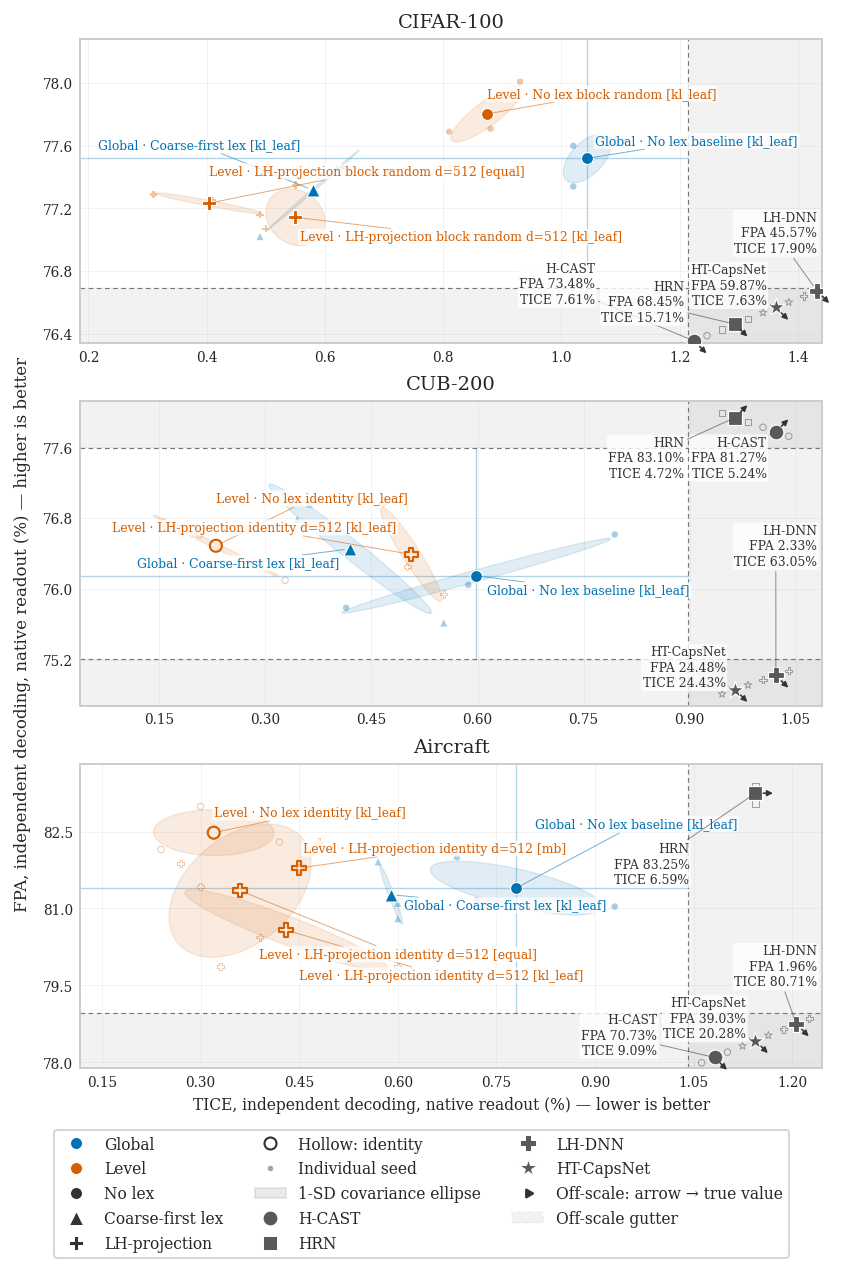

In [19]:
plot_tradeoff(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    reference_rows=reference_rows, reference_specs=REFERENCE_SPECS,
    encoding=ENCODING,
    # The channels cannot separate every pair in this matrix (see the encoding
    # check above), so the direct labels stay on and carry the remainder.
    point_labels='all',
    baseline_selector=canonical_baseline,
    # The widest run matrix in the study: give the panels extra height so the
    # direct labels have somewhere to go.
    panel_height=2.65,
    decoder=DECODER, readout=READOUT,
)

## Selected-Run Effects Across Hierarchy Levels

Each bar is the level-accuracy change of an available run from the canonical
no-lex baseline within the same dataset: global softmax, `kl_leaf`, orthonormal
frame. Deltas are computed per seed and then averaged, so only
seeds present in both runs contribute; the baseline itself and runs without a
matching baseline are omitted. Each panel has its own vertical scale, so compare
datasets through the printed values rather than the bar heights.

The CIFAR-100 ResNet-50 ablation bars are the exception flagged in the header:
their baseline here is WideResNet-28-8, so those bars mix the backbone change
with the pretraining change and are labelled accordingly.

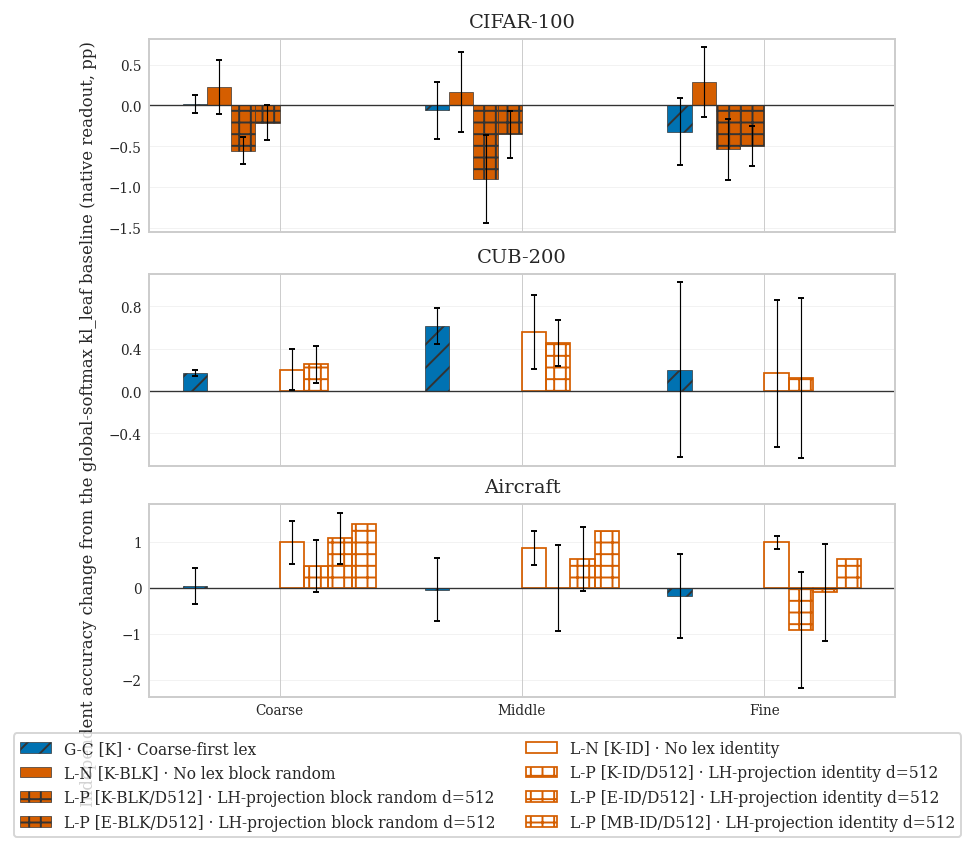

In [20]:
plot_level_accuracy_deltas(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    baseline_selector=canonical_baseline,
    baseline_name='the global-softmax kl_leaf baseline',
    # Bar labels spell out the whole configuration, so two columns per row.
    legend_ncol=2, panel_height=1.7,
    decoder=DECODER, readout=READOUT,
)

## Run and Pareto Summary

A run is Pareto-optimal within a dataset when no other run of the same model
family has both higher-or-equal FPA and lower-or-equal TICE, with at least one
strict improvement. Reference models are not part of this comparison. AHD and
weighted AP are reported as additional columns but do not enter the Pareto test.

In [21]:
print_summary(rows, DATASETS, label_width=18)


CIFAR-100
  run                 n  epoch           FPA               TICE              AHD               weighted AP       status
  L-N [K-BLK]         3  92.3 ± 7.5      77.80% ± 0.18     0.87% ± 0.06      0.437 ± 0.007     80.33% ± 0.21     Pareto-optimal
  G-N [K]             3  93.7 ± 5.0      77.52% ± 0.16     1.04% ± 0.04      0.444 ± 0.003     80.07% ± 0.20     dominated by L-N [K-BLK]
  G-C [K]             3  93.7 ± 3.8      77.32% ± 0.26     0.58% ± 0.08      0.446 ± 0.005     79.81% ± 0.19     Pareto-optimal
  L-P [E-BLK/D512]    3  96.3 ± 2.5      77.23% ± 0.07     0.40% ± 0.09      0.452 ± 0.002     79.61% ± 0.05     Pareto-optimal
  L-P [K-BLK/D512]    3  90.0 ± 4.4      77.14% ± 0.18     0.55% ± 0.05      0.462 ± 0.007     79.47% ± 0.19     dominated by L-P [E-BLK/D512]

CUB-200
  run                 n  epoch           FPA               TICE              AHD               weighted AP       status
  L-N [K-ID]          3  62.3 ± 13.2     76.49% ± 0.35     0.23% ± 0.09    